# Amélioration du modèle de survie Cox

Le but de ce modèle est d'améliorer le modèle de survie Cox présenté dans le benchmark


### 1. Data Collection

In [1]:
# Import necessary libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored , concordance_index_ipcw
from sklearn.impute import SimpleImputer
from sksurv.util import Surv

# Clinical Data
df = pd.read_csv("C:/Users/bourg/Documents/Centrale Nantes/EI3/Cours/Periode_1/APST1/Data_challenge/Data-Challenge-Prediction-de-Survie/raw_data/X_train/clinical_train.csv")
df_eval = pd.read_csv("C:/Users/bourg/Documents/Centrale Nantes/EI3/Cours/Periode_1/APST1/Data_challenge/Data-Challenge-Prediction-de-Survie/raw_data/X_test/clinical_test.csv")

# Molecular Data
maf_df = pd.read_csv("C:/Users/bourg/Documents/Centrale Nantes/EI3/Cours/Periode_1/APST1/Data_challenge/Data-Challenge-Prediction-de-Survie/raw_data/X_train/molecular_train.csv")
maf_eval = pd.read_csv("C:/Users/bourg/Documents/Centrale Nantes/EI3/Cours/Periode_1/APST1/Data_challenge/Data-Challenge-Prediction-de-Survie/raw_data/X_test/molecular_test.csv")

target_df = pd.read_csv("C:/Users/bourg/Documents/Centrale Nantes/EI3/Cours/Periode_1/APST1/Data_challenge/Data-Challenge-Prediction-de-Survie/raw_data/target_train.csv")
#target_df_test = pd.read_csv("C:/Users/bourg/Documents/Centrale Nantes/EI3/Cours/Periode_1/APST1/Data_challenge/Data-Challenge-Prediction-de-Survie/raw_data/target_test.csv")


In [2]:
print(df.shape)
df.head()


(3323, 9)


,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
0,P132697,MSK,14.0,2.8,0.2,0.7,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]"
1,P132698,MSK,1.0,7.4,2.4,0.1,11.6,42.0,"46,xx"
2,P116889,MSK,15.0,3.7,2.1,0.1,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]"
3,P132699,MSK,1.0,3.9,1.9,0.1,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]"
4,P132700,MSK,6.0,128.0,9.7,0.9,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]"


In [3]:
print(maf_df.shape)
maf_df.head()

(10935, 11)


,ID,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH
0,P100000,11,119149248.0,119149248.0,G,A,CBL,p.C419Y,non_synonymous_codon,0.0830,1308.0
1,P100000,5,131822301.0,131822301.0,G,T,IRF1,p.Y164*,stop_gained,0.0220,532.0
2,P100000,3,77694060.0,77694060.0,G,C,ROBO2,p.?,splice_site_variant,0.4100,876.0
3,P100000,4,106164917.0,106164917.0,G,T,TET2,p.R1262L,non_synonymous_codon,0.4300,826.0
4,P100000,2,25468147.0,25468163.0,ACGAAGAGGGGGTGTTC,A,DNMT3A,p.E505fs*141,frameshift_variant,0.0898,942.0


In [4]:
print(target_df.shape)
target_df.head()

(3323, 3)


,ID,OS_YEARS,OS_STATUS
0,P132697,1.115068,1.0
1,P132698,4.928767,0.0
2,P116889,2.043836,0.0
3,P132699,2.476712,1.0
4,P132700,3.145205,0.0


### 2. Data Cleaning and Preprocessing

#### Merge the molecular and clinical data

In [5]:
merged_df = pd.merge(df, maf_df, on="ID", how="inner") #inner join to keep only patients with both clinical and molecular data
print(merged_df.shape)
merged_df.head()

(10935, 19)


,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH
0,P132697,MSK,14.0,2.8,0.2,0.7,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]",21,44514780.0,44514780.0,C,T,U2AF1,p.R156H,non_synonymous_codon,0.3500,2620.0
1,P132697,MSK,14.0,2.8,0.2,0.7,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]",2,25457242.0,25457242.0,C,T,DNMT3A,p.R882H,non_synonymous_codon,0.4220,1850.0
2,P132697,MSK,14.0,2.8,0.2,0.7,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]",13,28602341.0,28602341.0,T,G,FLT3,p.N676T,non_synonymous_codon,0.0910,2112.0
3,P132697,MSK,14.0,2.8,0.2,0.7,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]",13,28608329.0,28608329.0,A,G,FLT3,p.L576P,non_synonymous_codon,0.1400,1967.0
4,P132697,MSK,14.0,2.8,0.2,0.7,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]",16,30747705.0,30747707.0,T,TCC,SRCAP,p.V2306fs*2,frameshift_variant,0.1477,1339.0


#### Check for duplicate rows

In [6]:
df = merged_df
df.duplicated().sum()

np.int64(0)

#### Identitfy columns data types

In [7]:
#print([df[col].dtype for col in df.columns])
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype != 'object']

print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)

Categorical columns: ['ID', 'CENTER', 'CYTOGENETICS', 'CHR', 'REF', 'ALT', 'GENE', 'PROTEIN_CHANGE', 'EFFECT']
Numerical columns: ['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT', 'START', 'END', 'VAF', 'DEPTH']


#### Count unique values in the categorical columns

In [8]:
df[cat_col].nunique()

ID                3026
CENTER              23
CYTOGENETICS      1115
CHR                 23
REF                406
ALT                332
GENE               124
PROTEIN_CHANGE    4686
EFFECT              16
dtype: int64

#### Calculate missing values as percentage of total values

In [9]:
round((df.isnull().sum() / df.shape[0]) * 100, 2)

ID                 0.00
CENTER             0.00
BM_BLAST           3.76
WBC                8.37
ANC                6.14
MONOCYTES         18.30
HB                 3.40
PLT                3.88
CYTOGENETICS      12.58
CHR                1.04
START              1.04
END                1.04
REF                1.04
ALT                1.04
GENE               0.00
PROTEIN_CHANGE     0.11
EFFECT             0.00
VAF                0.81
DEPTH              1.04
dtype: float64

There are minus than 20% missing values in all columns, so we decide to keep all columns for the analysis.

### Filling missing values

As a first approach, we will fill the missing values using the median for numerical columns and the mode for categorical columns.

In [10]:
df[num_col] = df[num_col].fillna(df[num_col].median())
df[cat_col] = df[cat_col].fillna(df[cat_col].mode().iloc[0])

round((df.isnull().sum() / df.shape[0]) * 100, 2)


ID                0.0
CENTER            0.0
BM_BLAST          0.0
WBC               0.0
ANC               0.0
MONOCYTES         0.0
HB                0.0
PLT               0.0
CYTOGENETICS      0.0
CHR               0.0
START             0.0
END               0.0
REF               0.0
ALT               0.0
GENE              0.0
PROTEIN_CHANGE    0.0
EFFECT            0.0
VAF               0.0
DEPTH             0.0
dtype: float64

#### Detect outliers 

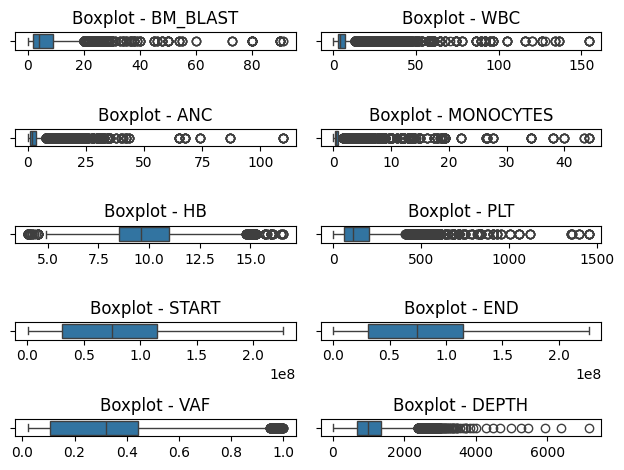

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(5, 2)  # 5 lignes, 2 colonnes
axes = axes.flatten()  # pour indexer facilement

for i, col in enumerate(num_col):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot - {col}")
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

The boxplot analysis shows the presence of outliers in the majority of the features. As they come from clinical variations, we decide to keep them.

#### Data formating

Depends of the used model.

### 3. Exploratory Data Analysis (EDA)

#### 3.1 Univariate analysis

In [12]:
clinical_features = df.columns[1:9]
molecular_features = df.columns[10:]

cat_col_clinic = [col for col in clinical_features if df[col].dtype == 'object']
num_col_clinic = [col for col in clinical_features if df[col].dtype != 'object']
cat_col_molec = [col for col in molecular_features if df[col].dtype == 'object']
num_col_molec = [col for col in molecular_features if df[col].dtype != 'object']

print('Categorical clinical columns:', cat_col_clinic)
print('Numerical clinical columns:', num_col_clinic)
print('Categorical molecular columns:', cat_col_molec)
print('Numerical molecular columns:', num_col_molec)

Categorical clinical columns: ['CENTER', 'CYTOGENETICS']
Numerical clinical columns: ['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT']
Categorical molecular columns: ['REF', 'ALT', 'GENE', 'PROTEIN_CHANGE', 'EFFECT']
Numerical molecular columns: ['START', 'END', 'VAF', 'DEPTH']


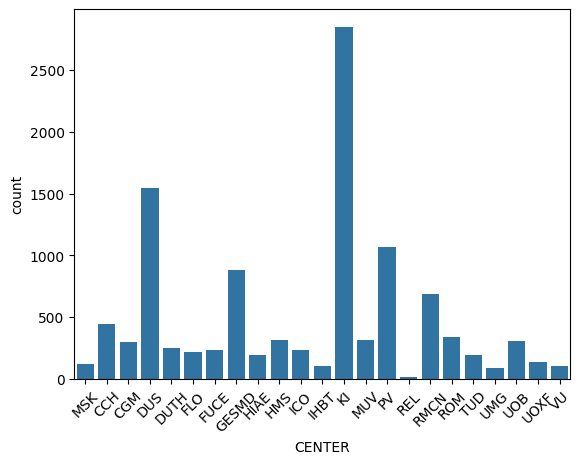

In [38]:
plt.figure()
sns.countplot(x=df["CENTER"])
plt.xticks(rotation=45)
plt.show()

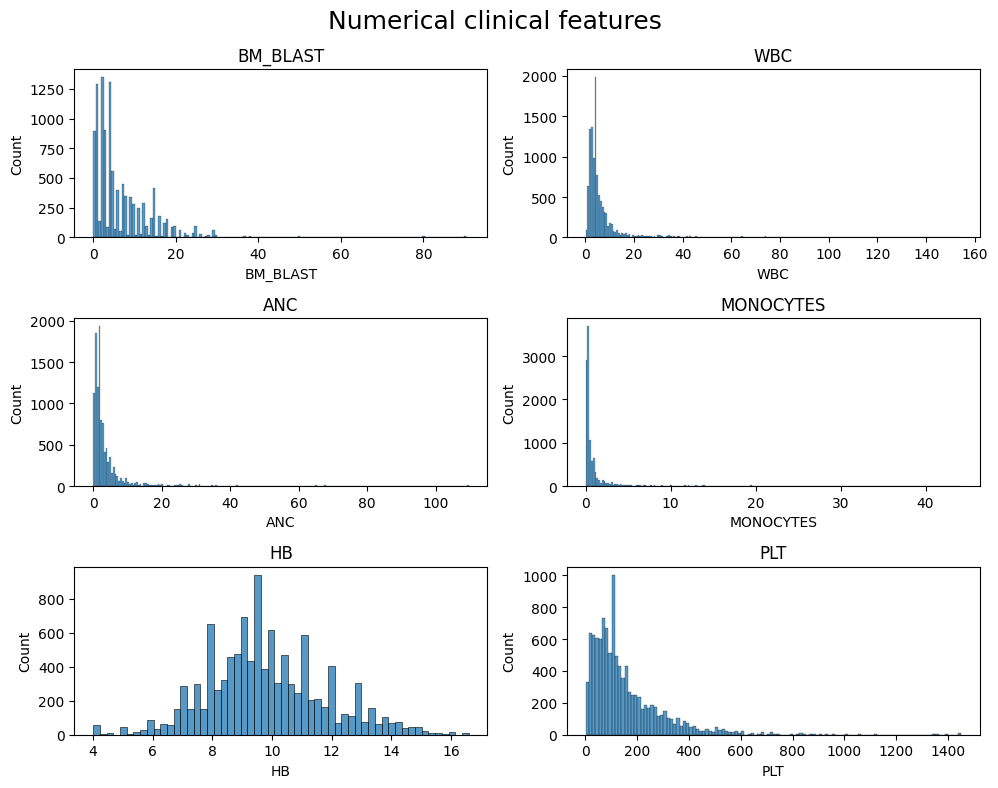

In [52]:
fig, axes = plt.subplots(3, 2, figsize=(10, 8))

axes = axes.flatten()

for ax, col in zip(axes, num_col_clinic):
    sns.histplot(df[col], ax=ax)
    ax.set_title(col)

fig.suptitle("Numerical clinical features", fontsize=18)
plt.tight_layout()
plt.show()

HB distribution seems Gaussian, the others seems Chi-squared and linked.

In [ ]:
df[cat_col_molec].nunique()

REF                406
ALT                332
GENE               124
PROTEIN_CHANGE    4686
EFFECT              16
dtype: int64

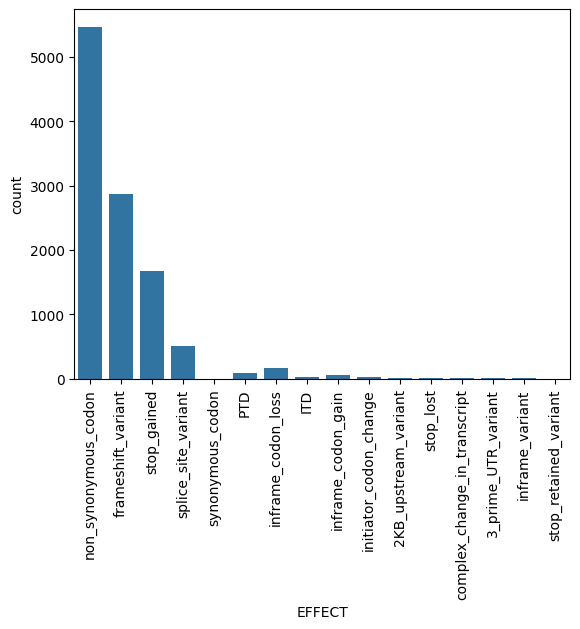

In [60]:
plt.figure()
sns.countplot(x=df["EFFECT"])
plt.xticks(rotation=90)
plt.show()

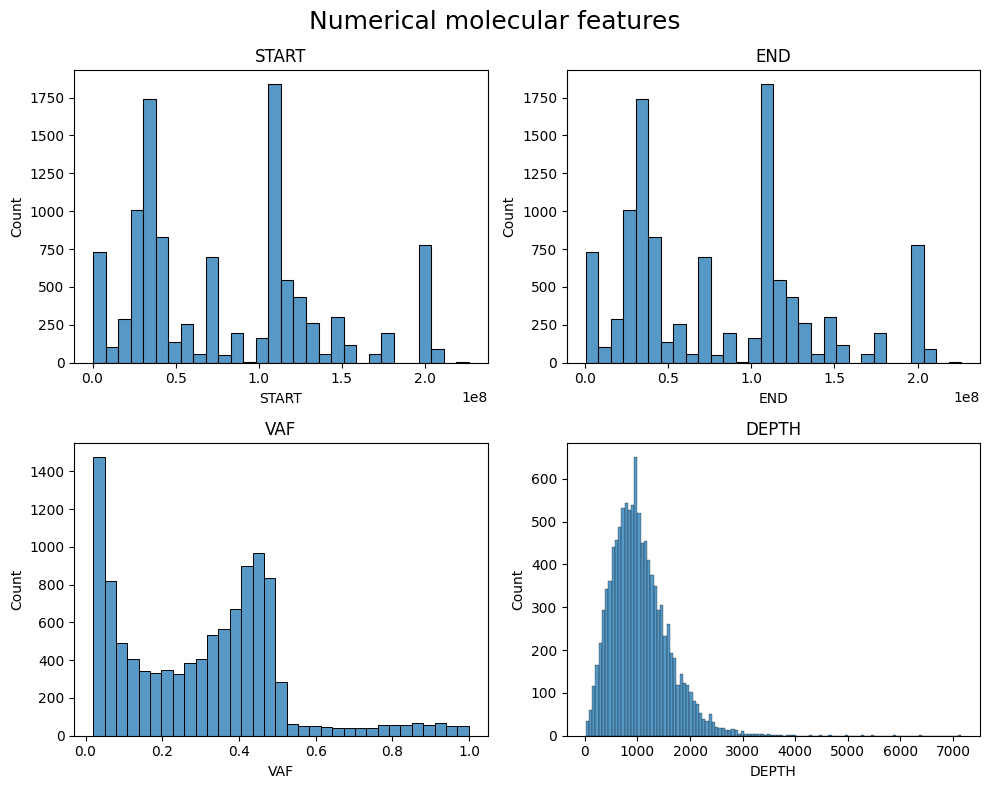

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes = axes.flatten()

for ax, col in zip(axes, num_col_molec):
    sns.histplot(df[col], ax=ax)
    ax.set_title(col)

fig.suptitle("Numerical molecular features", fontsize=18)
plt.tight_layout()
plt.show()

The depth distribution seems Gaussian.

#### 3.2 Multi-variate analysis

Numerical-Numerical

<Axes: >

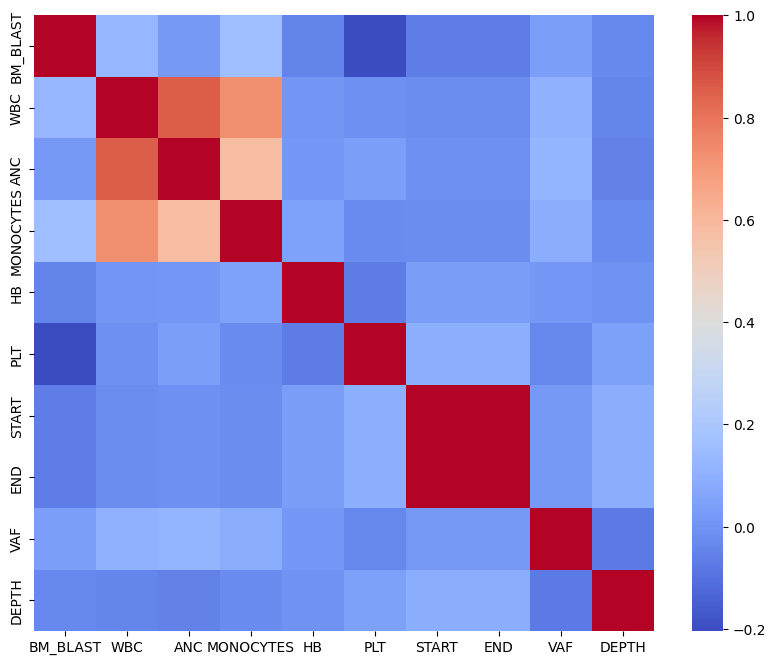

In [63]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_col].corr(), annot=False, cmap="coolwarm")

We see strong correlation between (ANC,WBC), (MONOCYTES,WBC) and (MONOCYTES, ANC)

Categorial-Categorial